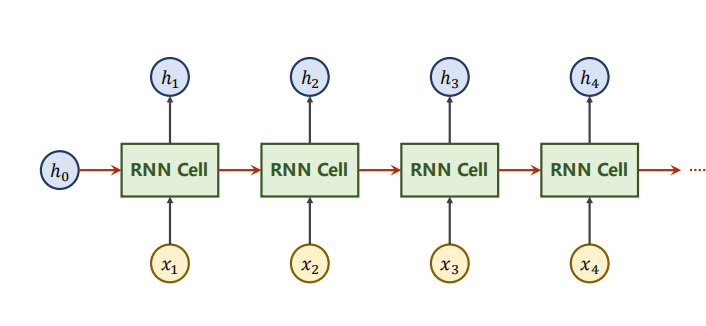
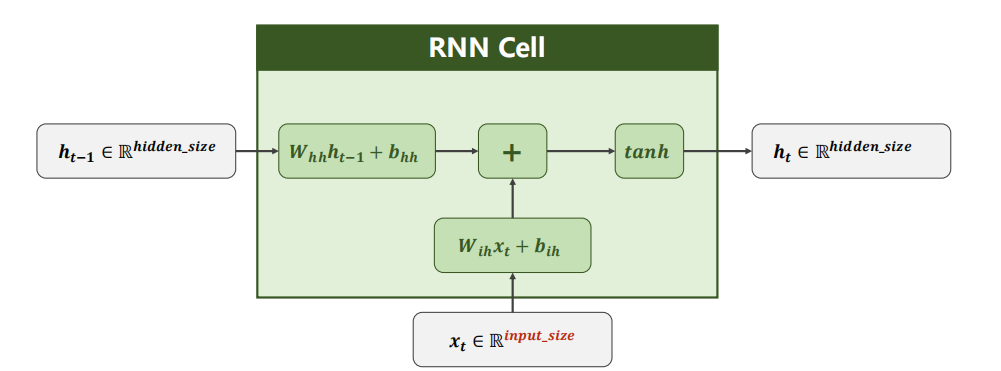

In [3]:
import torch

batch_size = 1
seq_len = 3
input_size = 4
hidden_size = 2
cell = torch.nn.RNNCell(input_size=input_size, hidden_size=hidden_size)
dataset = torch.randn(seq_len, batch_size, input_size)
hidden = torch.zeros(batch_size, hidden_size)
# 遍历时得到的input比dataset少一个维度，也就是取出的每个input是(batch_size,input_size)
for idx, input in enumerate(dataset):
    print("=" * 20, idx, "=" * 20)
    print("Input size:", input.shape)
    hidden = cell(input, hidden)
    print("output size:", hidden.shape)
    print(hidden)

==================== 0 ====================
Input size: torch.Size([1, 4])
output size: torch.Size([1, 2])
tensor([[0.0057, 0.4242]], grad_fn=<TanhBackward0>)
==================== 1 ====================
Input size: torch.Size([1, 4])
output size: torch.Size([1, 2])
tensor([[ 0.4062, -0.1851]], grad_fn=<TanhBackward0>)
==================== 2 ====================
Input size: torch.Size([1, 4])
output size: torch.Size([1, 2])
tensor([[ 0.3870, -0.0487]], grad_fn=<TanhBackward0>)


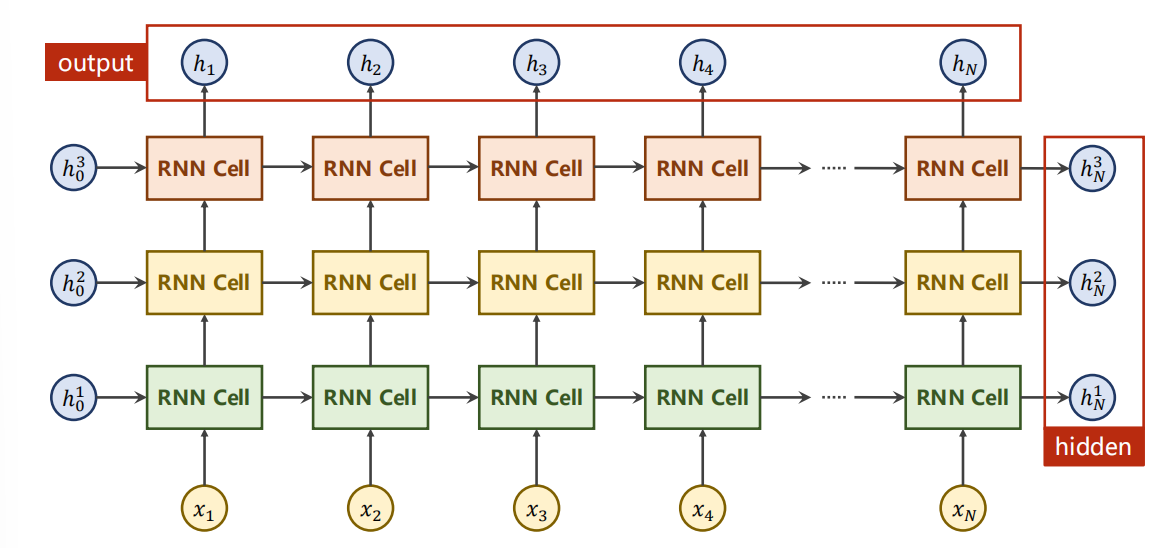
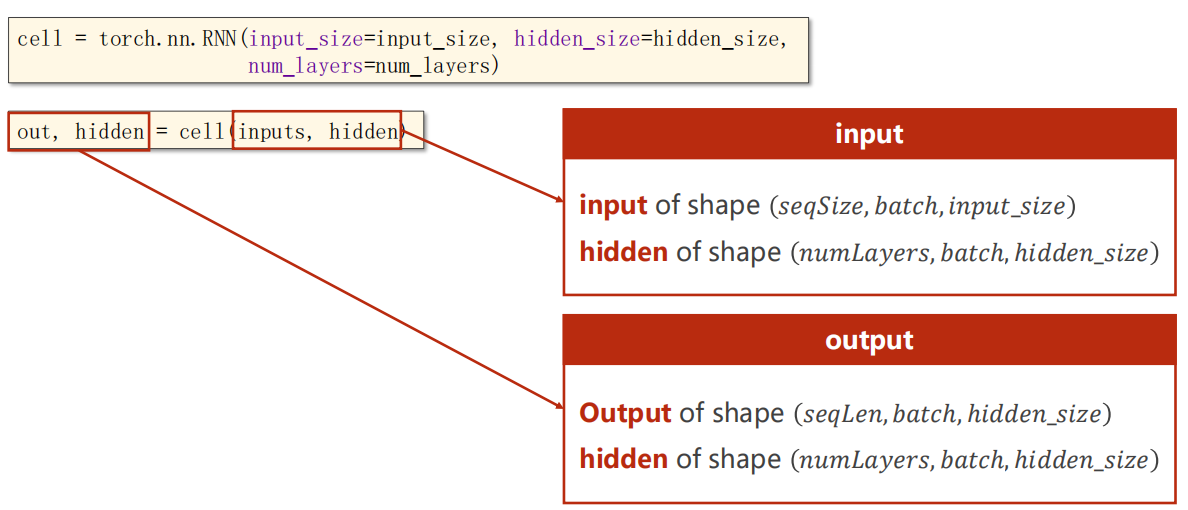

In [ ]:
num_layers = 1
# RNN里面还有一个参数batch_first，若把它设为True，则inputs维度应该是(batch_size,seq_len,input_size)
cell = torch.nn.RNN(
    input_size=input_size, hidden_size=hidden_size, num_layers=num_layers
)
inputs = torch.randn(seq_len, batch_size, input_size)
hidden = torch.zeros(num_layers, batch_size, hidden_size)
out, hidden = cell(inputs, hidden)

接下来我们要用RNN完成以下的字符串转换学习
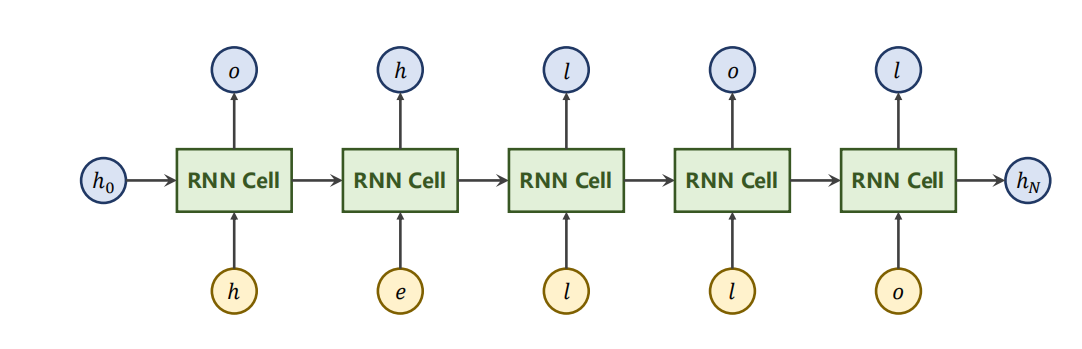

In [14]:
hidden_size = 4
dic = ["h", "e", "l", "o"]
x_data = [0, 1, 2, 2, 3]
y_data = [3, 0, 2, 3, 2]
one_hot_lookup = [[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]]
x_one_hot = [one_hot_lookup[x] for x in x_data]
inputs = torch.tensor(x_one_hot, dtype=torch.float32).view(-1, batch_size, input_size)
labels = torch.tensor(y_data).view(
    -1, 1
)  # 和x的seqlen一样，便于之后遍历时分别取出每一轮的答案


class Model(torch.nn.Module):
    def __init__(self, input_size, hidden_size, batch_size):
        super().__init__()
        self.batch_size = batch_size
        self.hidden_size = hidden_size
        self.cell = torch.nn.RNNCell(input_size=input_size, hidden_size=hidden_size)

    def forward(self, x, y):
        return self.cell(x, y)

    def init_hidden(self):
        return torch.zeros(self.batch_size, self.hidden_size, dtype=torch.float32)


# RNN的特点之一就是同一层不同时间步共享参数，所以只创建一个Model对象，更新这一套参数
net = Model(input_size, hidden_size, batch_size)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=0.1)
for epoch in range(15):
    loss = torch.tensor(0.0)
    hidden = net.init_hidden()
    optimizer.zero_grad()
    print("predicted string: ", end="")
    for input, label in zip(inputs, labels):
        hidden = net(input, hidden)
        loss += criterion(hidden, label)
        _, idx = hidden.max(dim=1)
        print(dic[idx.item()], end="")
    print(",loss=", loss)
    loss.backward()
    optimizer.step()

predicted string: heeeh,loss= tensor(7.6253, grad_fn=<AddBackward0>)
predicted string: hlloh,loss= tensor(5.7931, grad_fn=<AddBackward0>)
predicted string: hllol,loss= tensor(5.0808, grad_fn=<AddBackward0>)
predicted string: hllol,loss= tensor(4.7153, grad_fn=<AddBackward0>)
predicted string: ohlol,loss= tensor(4.4446, grad_fn=<AddBackward0>)
predicted string: ohlol,loss= tensor(4.1842, grad_fn=<AddBackward0>)
predicted string: ohlol,loss= tensor(3.9200, grad_fn=<AddBackward0>)
predicted string: ohlol,loss= tensor(3.6503, grad_fn=<AddBackward0>)
predicted string: ohlol,loss= tensor(3.3765, grad_fn=<AddBackward0>)
predicted string: ohlol,loss= tensor(3.1047, grad_fn=<AddBackward0>)
predicted string: ohlol,loss= tensor(2.8434, grad_fn=<AddBackward0>)
predicted string: ohlol,loss= tensor(2.6178, grad_fn=<AddBackward0>)
predicted string: ohlol,loss= tensor(2.4601, grad_fn=<AddBackward0>)
predicted string: ohlol,loss= tensor(2.3598, grad_fn=<AddBackward0>)
predicted string: ohlol,loss= tens

In [ ]:
# 用RNN的版本
hidden_size = 4
dic = ["h", "e", "l", "o"]
x_data = [0, 1, 2, 2, 3]
y_data = [3, 0, 2, 3, 2]
one_hot_lookup = [[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]]
x_one_hot = [one_hot_lookup[x] for x in x_data]
inputs = torch.tensor(x_one_hot, dtype=torch.float32).view(batch_size, -1, input_size)
labels = torch.tensor(y_data)


class Model(torch.nn.Module):
    def __init__(self, input_size, hidden_size, batch_size, num_layers):
        super().__init__()
        self.batch_size = batch_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.input_size = input_size
        self.cell = torch.nn.RNN(
            input_size=input_size, hidden_size=hidden_size, num_layers=num_layers
        )

    def forward(self, x, y):
        out, _ = self.cell(x, y)
        return out.view(-1, self.hidden_size)

    def init_hidden(self):
        return torch.zeros(
            self.num_layers, self.batch_size, self.hidden_size, dtype=torch.float32
        )


# RNN的特点之一就是同一层不同时间步共享参数，所以只创建一个Model对象，更新这一套参数
net = Model(input_size, hidden_size, batch_size, num_layers)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=0.1)
for epoch in range(15):
    hidden = net.init_hidden()
    optimizer.zero_grad()
    out = net(inputs, hidden)
    loss = criterion(out, labels)
    loss.backward()
    optimizer.step()
    _, idx = out.max(dim=1)
    # "".join() 第一个字符串表示分隔符，join表示拼接
    print("predicted string: ", "".join(dic[x.item()] for x in idx), end="")
    print(",loss=", loss.item())

predicted string:  eeeel,loss= 1.5080567598342896
predicted string:  eelll,loss= 1.2265204191207886
predicted string:  ohlll,loss= 1.0543766021728516
predicted string:  ohlll,loss= 0.9518728256225586
predicted string:  ohlol,loss= 0.8754118084907532
predicted string:  ohlol,loss= 0.8106223344802856
predicted string:  ohlol,loss= 0.7572125792503357
predicted string:  ohlol,loss= 0.7108213305473328
predicted string:  ohlol,loss= 0.6673921346664429
predicted string:  ohlol,loss= 0.625557541847229
predicted string:  ohlol,loss= 0.5860955119132996
predicted string:  ohlol,loss= 0.5519586801528931
predicted string:  ohlol,loss= 0.5250104665756226
predicted string:  ohlol,loss= 0.5048083066940308
predicted string:  ohlol,loss= 0.4899233281612396


embedding方法

In [ ]:
hidden_size = 8
embedding_size = 10
num_class = 4
num_layers = 2
dic = ["h", "e", "l", "o"]
x_data = [0, 1, 2, 2, 3]
y_data = [3, 0, 2, 3, 2]
inputs = torch.tensor(x_data, dtype=torch.long).view(batch_size, -1)
labels = torch.tensor(y_data)


class Model(torch.nn.Module):
    def __init__(self, input_size, hidden_size, batch_size, num_layers):
        super().__init__()
        self.batch_size = batch_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.input_size = input_size
        # 有input_size个编号，每个编号对应一个embedding_size长度的向量，根据这个表进行embedding,
        # 也就是对每个输入数字查表赋向量，所以要求input是int型tensor,作为查表索引，
        # 也就是原先的每个整数会转换为一个embedding向量，
        # 也就是embedding后维度会增加
        self.emb = torch.nn.Embedding(input_size, embedding_size)
        self.cell = torch.nn.RNN(
            input_size=embedding_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )  # batch_first要求input的shape第0维是batch_size,但不改变hidden的shape
        self.linear = torch.nn.Linear(hidden_size, num_class)

    def forward(self, x, y):
        x = self.emb(x)
        out, _ = self.cell(x, y)
        out = out.view(-1, self.hidden_size)
        out = self.linear(out)
        return out

    def init_hidden(self):
        return torch.zeros(
            self.num_layers, self.batch_size, self.hidden_size, dtype=torch.float32
        )


net = Model(input_size, hidden_size, batch_size, num_layers)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=0.1)
for epoch in range(15):
    hidden = net.init_hidden()
    optimizer.zero_grad()
    out = net(inputs.long(), hidden)
    loss = criterion(out, labels)
    loss.backward()
    optimizer.step()
    _, idx = out.max(dim=1)
    # "".join() 第一个字符串表示分隔符，join表示拼接
    print("predicted string: ", "".join(dic[x.item()] for x in idx), end="")
    print(",loss=", loss.item())

predicted string:  eheel,loss= 1.368636965751648
predicted string:  ooool,loss= 0.9808646440505981
predicted string:  ohlol,loss= 0.5295226573944092
predicted string:  ohlol,loss= 0.23292967677116394
predicted string:  ohlol,loss= 0.10096726566553116
predicted string:  ohlol,loss= 0.0457783043384552
predicted string:  ohlol,loss= 0.02277330309152603
predicted string:  ohlol,loss= 0.011981005780398846
predicted string:  ohlol,loss= 0.006553865969181061
predicted string:  ohlol,loss= 0.0038828575052320957
predicted string:  ohlol,loss= 0.002482140203937888
predicted string:  ohlol,loss= 0.0016765706241130829
predicted string:  ohlol,loss= 0.0011932033812627196
predicted string:  ohlol,loss= 0.00089204654796049
predicted string:  ohlol,loss= 0.0006938908481970429


embedding比one-hot的优势
- one-hot相当于一个索引对应一个单词，维度较高，计算量较大，而embedding的元素为float型，可以在低维状态下表示大量数字的字典向量
- one-hot数据较为稀疏，一个单词对应向量通常只有一个1，其它均为0
- one-hot是硬编码，程序运行过程中不会变，不同单词之间的关系没法通过训练在编码中体现出来，而embedding是可训练编码，向量中的数可以在训练过程中不断改变，于是可以逐渐形成单词之间的关系，比如：猫和狗都是家里养的动物，所以它们会出现在相似的上下文语境中，训练过程中就会使得它们的向量逐渐靠近，于是猫和狗的关系就逐渐通过训练体现出来了。